# 04 · Model Training, Evaluation and 2026 Forecast

Compare **12 models across four tiers**, select by walk-forward validation, and forecast
2026.

| Tier | Models |
|---|---|
| Baselines | naive last · moving average 3/6 · seasonal naive · seasonal naive + drift |
| Linear | linear regression · ridge |
| Classical time series | Holt-Winters · SARIMA · Prophet *(optional)* |
| Tree ensembles | random forest · gradient boosting · XGBoost |

Evaluation is **rolling-origin (expanding-window) cross-validation** — at each origin the
model refits on everything observed so far and predicts one month ahead. Unlike a random
K-fold split, it never lets the model see the future.

In [1]:
import sys, warnings
from pathlib import Path

# Make the project root importable when running from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

from src.config import get_settings, configure_logging

settings = get_settings()
configure_logging(settings, "WARNING")
print("Project root:", ROOT)
print("MC:", settings.mc_name, "| target:", settings.target, "| forecast year:", settings.forecast_year)

Project root: /Users/jayedalammansur/Exchange Activity Prediction Platform
MC: AIESEC in India | target: APP | forecast year: 2026


In [2]:
from src.preprocessing.cleaning import load_exchange_dataset
from src.models import forecasting as FC
from src.models.train import build_history_series

panel = load_exchange_dataset(settings)
history = build_history_series(panel, settings)
print(f"{len(history)} months: {history.index.min():%Y-%m} -> {history.index.max():%Y-%m}")
history.tail(6)

48 months: 2022-01 -> 2025-12


2025-07-01    1510.0
2025-08-01    1315.0
2025-09-01    1331.0
2025-10-01    1482.0
2025-11-01    1569.0
2025-12-01    1950.0
Freq: MS, Name: APP, dtype: float64

## 1. Build the candidate registry

In [3]:
registry = FC.build_model_registry(settings)
pd.DataFrame(
    [{"model": name, "family": m.family, "explainability": m.explainability}
     for name, m in registry.items()]
).sort_values(["family", "model"]).reset_index(drop=True)

2026-08-02 17:13:11 | WARNING  | src.models.forecasting       | prophet is not installed - skipping the Prophet candidate (pip install prophet to enable it)


,model,family,explainability
0,moving_average_3,baseline,1
1,moving_average_6,baseline,1
2,naive_last,baseline,1
3,seasonal_naive,baseline,1
4,seasonal_naive_drift,baseline,1
5,gradient_boosting,ensemble,4
6,random_forest,ensemble,4
7,xgboost,ensemble,4
8,linear_regression,linear,2
9,ridge,linear,2


## 2. Walk-forward backtest

24 origins × 12 models. Each origin refits from scratch — a fresh model instance per
fold, so no state leaks between them.

In [4]:
backtest = FC.rolling_origin_backtest(history, registry, settings, panel)
backtest.metrics[["model", "family", "MAE", "RMSE", "MAPE", "sMAPE",
                  "error_std", "max_abs_error", "origins_evaluated"]].round(2)

,model,family,MAE,RMSE,MAPE,sMAPE,error_std,max_abs_error,origins_evaluated
0,ridge,linear,92.49,116.32,6.43,6.23,70.55,356.73,24
1,holt_winters,timeseries,101.44,138.28,7.30,6.94,93.98,314.39,24
2,random_forest,ensemble,116.94,148.25,8.00,7.90,91.11,385.54,24
3,linear_regression,linear,123.79,152.12,8.58,8.49,88.42,331.68,24
4,xgboost,ensemble,124.37,160.18,8.67,8.60,100.96,407.59,24
5,gradient_boosting,ensemble,126.20,156.19,8.92,8.79,92.03,379.52,24
6,seasonal_naive_drift,baseline,128.42,170.40,9.18,8.48,112.00,360.24,24
7,seasonal_naive,baseline,135.71,157.05,9.25,9.85,79.04,269.00,24
8,sarima,timeseries,160.28,306.97,11.69,9.84,261.80,1213.37,24
9,moving_average_6,baseline,188.92,236.23,12.62,12.75,141.82,540.83,24


### The headline finding

Note where the tree ensembles land. With 36 training rows against 40 features,
**regularisation beats capacity** — a penalised linear model wins, and XGBoost sits
behind plain Holt-Winters. This is exactly why the suite spans four tiers rather than
assuming the most sophisticated model is best.

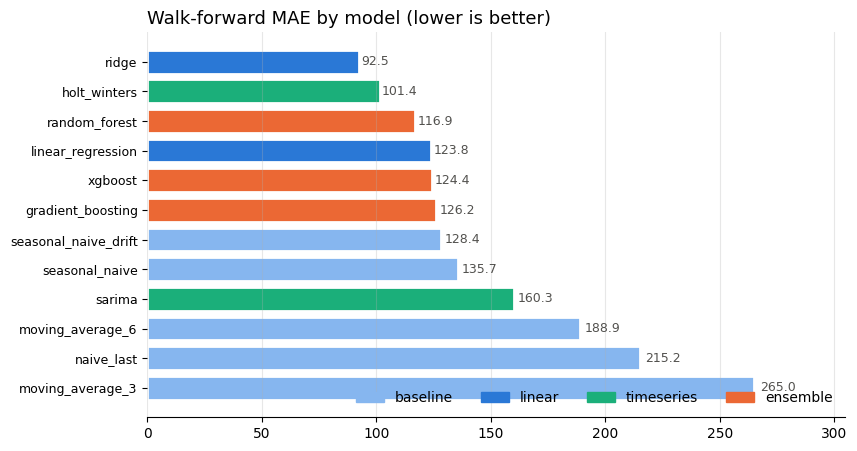

Best per family:
  baseline     seasonal_naive_drift   MAE  128.42  MAPE  9.18%
  ensemble     random_forest          MAE  116.94  MAPE  8.00%
  linear       ridge                  MAE   92.49  MAPE  6.43%
  timeseries   holt_winters           MAE  101.44  MAPE  7.30%


In [5]:
metrics = backtest.metrics.sort_values("MAE")

fig, ax = plt.subplots(figsize=(9, 5))
ordered = metrics.iloc[::-1]
family_colors = {"baseline": "#86b6ef", "linear": "#2a78d6",
                 "timeseries": "#1baf7a", "ensemble": "#eb6834"}
ax.barh(ordered["model"], ordered["MAE"],
        color=[family_colors[f] for f in ordered["family"]],
        edgecolor="white", linewidth=2)
for i, (_, r) in enumerate(ordered.iterrows()):
    ax.text(r["MAE"] * 1.01, i, f"{r['MAE']:.1f}", va="center", fontsize=9, color="#52514e")
ax.set_xlim(0, ordered["MAE"].max() * 1.15)
ax.set_title("Walk-forward MAE by model (lower is better)", loc="left", fontsize=13)
ax.tick_params(axis="y", labelsize=9)
ax.grid(axis="x", alpha=0.3)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in family_colors.values()]
ax.legend(handles, family_colors.keys(), frameon=False, ncols=4, loc="lower right")
plt.show()

print("Best per family:")
for family, group in metrics.groupby("family"):
    best = group.iloc[0]
    print(f"  {family:<12} {best['model']:<22} MAE {best['MAE']:7.2f}  MAPE {best['MAPE']:5.2f}%")

## 3. Model selection

1. Rank by MAE.
2. Everything within **5%** of the best is tied on accuracy — a 2% gap over 24 origins is
   noise, not signal.
3. Break ties with `0.5 × accuracy + 0.3 × stability + 0.2 × explainability`.

Accuracy inside the band is scored against the *tolerance width*, not min-max normalised
across the tied set — min-max would re-inflate the very difference just declared
negligible.

In [6]:
best_name, evaluation = FC.select_best_model(backtest.metrics, settings)
print("Selected:", best_name)
evaluation[["model", "family", "MAE", "error_std", "explainability_rank",
            "within_tolerance", "composite_score", "selected"]].round(3)

Selected: ridge


,model,family,MAE,error_std,explainability_rank,within_tolerance,composite_score,selected
0,ridge,linear,92.485,70.551,2.0,True,0.0,True
1,holt_winters,timeseries,101.441,93.979,3.0,False,NaN,False
2,random_forest,ensemble,116.943,91.114,4.0,False,NaN,False
3,linear_regression,linear,123.789,88.415,2.0,False,NaN,False
4,xgboost,ensemble,124.366,100.956,4.0,False,NaN,False
5,gradient_boosting,ensemble,126.195,92.031,4.0,False,NaN,False
6,seasonal_naive_drift,baseline,128.418,111.998,1.0,False,NaN,False
7,seasonal_naive,baseline,135.708,79.040,1.0,False,NaN,False
8,sarima,timeseries,160.285,261.800,3.0,False,NaN,False
9,moving_average_6,baseline,188.924,141.823,1.0,False,NaN,False


## 4. Refit on the full history and inspect the fit

Residuals: n=24  mean=-45.3  std=107.1
95% empirical range: [-271, +144]


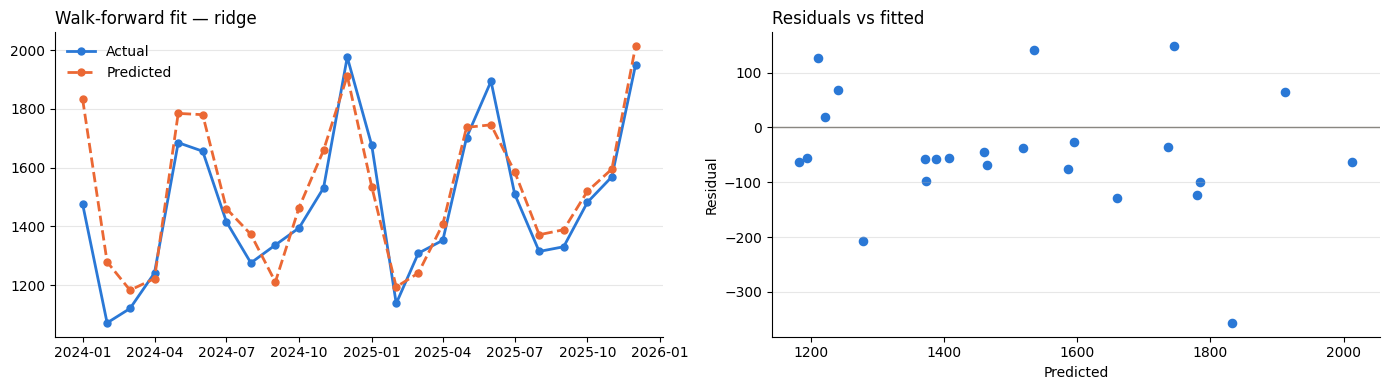

In [7]:
model = registry[best_name]
model.fit(history, panel)

residuals = backtest.residuals[best_name]
print(f"Residuals: n={len(residuals)}  mean={residuals.mean():+.1f}  std={residuals.std():.1f}")
print(f"95% empirical range: [{np.quantile(residuals, 0.025):+.0f}, {np.quantile(residuals, 0.975):+.0f}]")

subset = backtest.predictions[backtest.predictions["model"] == best_name].sort_values("date")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(pd.to_datetime(subset["date"]), subset["y_true"], marker="o", markersize=5,
             linewidth=2, color="#2a78d6", label="Actual")
axes[0].plot(pd.to_datetime(subset["date"]), subset["y_pred"], marker="o", markersize=5,
             linewidth=2, linestyle="--", color="#eb6834", label="Predicted")
axes[0].set_title(f"Walk-forward fit — {best_name}", loc="left", fontsize=12)
axes[0].legend(frameon=False)

axes[1].axhline(0, color="#898781", linewidth=1)
axes[1].scatter(subset["y_pred"], subset["y_true"] - subset["y_pred"], color="#2a78d6", s=35)
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs fitted", loc="left", fontsize=12)

for ax in axes:
    ax.grid(axis="y", alpha=0.3)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
plt.tight_layout(); plt.show()

### Feature importance (when the winner exposes it)

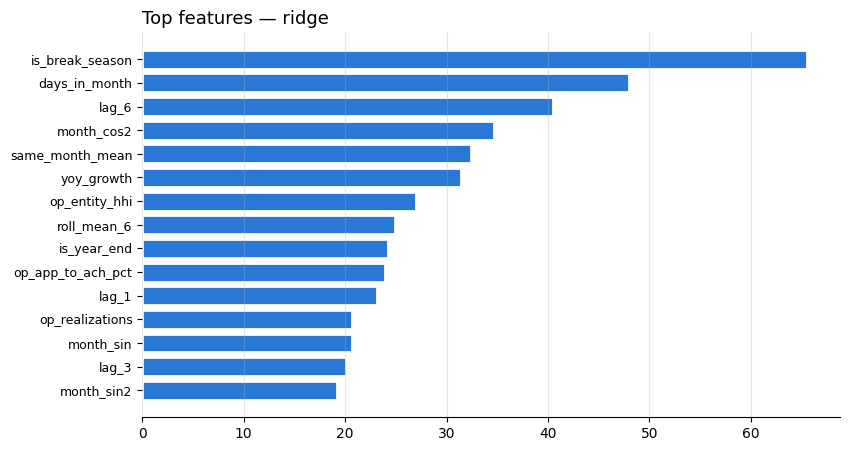

,feature,importance
0,is_break_season,65.4905
1,days_in_month,47.9526
2,lag_6,40.4735
3,month_cos2,34.6825
4,same_month_mean,32.4260
5,yoy_growth,31.4519
6,op_entity_hhi,27.0336
7,roll_mean_6,24.8858
8,is_year_end,24.2464
9,op_app_to_ach_pct,23.9465


In [8]:
if isinstance(model, FC.SklearnRecursiveForecaster):
    importances = model.feature_importances()
    if importances is not None:
        top = importances.head(15).iloc[::-1]
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.barh(top["feature"], top["importance"], color="#2a78d6",
                edgecolor="white", linewidth=2)
        ax.set_title(f"Top features — {best_name}", loc="left", fontsize=13)
        ax.tick_params(axis="y", labelsize=9)
        ax.grid(axis="x", alpha=0.3)
        for side in ("top", "right", "left"):
            ax.spines[side].set_visible(False)
        plt.show()
        display(importances.head(10).round(4))
else:
    print(f"{best_name} does not expose feature importances.")

## 5. Forecast 2026 with prediction intervals

Intervals are empirical — built from the model's own walk-forward residuals rather than
a parametric assumption — and widened by `√h` as the horizon extends.

In [9]:
forecast = FC.forecast_with_intervals(model, horizon=12, residuals=residuals, confidence=0.95)
forecast["month"] = pd.date_range("2026-01-01", periods=12, freq="MS").strftime("%b %Y")
forecast[["month", "forecast", "lower", "upper"]].round(0)

,month,forecast,lower,upper
0,Jan 2026,1682.0,1411.0,1826.0
1,Feb 2026,1175.0,792.0,1379.0
2,Mar 2026,1330.0,860.0,1579.0
3,Apr 2026,1437.0,895.0,1725.0
4,May 2026,1741.0,1135.0,2063.0
5,Jun 2026,1814.0,1151.0,2167.0
6,Jul 2026,1556.0,839.0,1936.0
7,Aug 2026,1386.0,620.0,1793.0
8,Sep 2026,1398.0,586.0,1830.0
9,Oct 2026,1541.0,685.0,1997.0


## 6. Activity levels

The literal brief (quartiles of raw history) **breaks on a growing series** — every 2026
month clears the 2022–2025 75th percentile, so all twelve come out "High" and the label
says nothing. Compare all three methods below.

In [10]:
values = forecast["forecast"].to_numpy()

comparison = pd.DataFrame({"month": forecast["month"],
                           "predicted": np.rint(values).astype(int)})
for method in ("trend_adjusted", "historical_quartiles", "forecast_quartiles"):
    labels, thresholds = FC.assign_activity_levels(values, history, settings, method)
    comparison[method] = labels

display(comparison)

print("Label distribution per method:")
for method in ("trend_adjusted", "historical_quartiles", "forecast_quartiles"):
    counts = comparison[method].value_counts().to_dict()
    print(f"  {method:<22} {counts}")
print("\nNote that historical_quartiles produces NO Low months at all: the growth trend\n"
      "lifts the whole of 2026 above the historical median, so its bottom quartile is\n"
      "unreachable and the scale silently loses a category. Push the trend harder and it\n"
      "degenerates completely to all-High. That is why trend_adjusted\n"
      "(ratio-to-centred-moving-average) is the default.")

,month,predicted,trend_adjusted,historical_quartiles,forecast_quartiles
0,Jan 2026,1682,Medium,High,Medium
1,Feb 2026,1175,Low,Medium,Low
2,Mar 2026,1330,Low,Medium,Low
3,Apr 2026,1437,Medium,Medium,Medium
4,May 2026,1741,High,High,High
5,Jun 2026,1814,High,High,High
6,Jul 2026,1556,Medium,High,Medium
7,Aug 2026,1386,Medium,Medium,Low
8,Sep 2026,1398,Medium,Medium,Medium
9,Oct 2026,1541,Medium,High,Medium


Label distribution per method:
  trend_adjusted         {'Medium': 7, 'High': 3, 'Low': 2}
  historical_quartiles   {'High': 7, 'Medium': 5}
  forecast_quartiles     {'Medium': 6, 'Low': 3, 'High': 3}

Note that historical_quartiles produces NO Low months at all: the growth trend
lifts the whole of 2026 above the historical median, so its bottom quartile is
unreachable and the scale silently loses a category. Push the trend harder and it
degenerates completely to all-High. That is why trend_adjusted
(ratio-to-centred-moving-average) is the default.


## 7. Persist the model and write the deliverable

In [11]:
from src.models.train import generate_predictions, save_artifacts, train_and_select

artifacts = train_and_select(panel, settings)
save_artifacts(artifacts, settings)
predictions = generate_predictions(artifacts, settings)

predictions[["Month", "Predicted Applications", "Activity Level", "lower_95", "upper_95"]]

2026-08-02 17:13:36 | WARNING  | src.models.forecasting       | prophet is not installed - skipping the Prophet candidate (pip install prophet to enable it)


,Month,Predicted Applications,Activity Level,lower_95,upper_95
0,Jan 2026,1682,Medium,1411,1826
1,Feb 2026,1175,Low,792,1379
2,Mar 2026,1330,Low,860,1579
3,Apr 2026,1437,Medium,895,1725
4,May 2026,1741,High,1135,2063
5,Jun 2026,1814,High,1151,2167
6,Jul 2026,1556,Medium,839,1936
7,Aug 2026,1386,Medium,620,1793
8,Sep 2026,1398,Medium,586,1830
9,Oct 2026,1541,Medium,685,1997


## 8. Summary

In [12]:
total = int(predictions["Predicted Applications"].sum())
peak = predictions.loc[predictions["Predicted Applications"].idxmax()]
high = predictions[predictions["Activity Level"] == "High"]["Month"].tolist()
low = predictions[predictions["Activity Level"] == "Low"]["Month"].tolist()
last_year = int(panel[panel["year"] == panel["year"].max()][settings.target].sum())

print(f"Model                : {artifacts.best_model_name}")
print(f"Backtest MAE / MAPE  : {artifacts.metadata['backtest_MAE']:.1f} / "
      f"{artifacts.metadata['backtest_MAPE']:.2f}%")
print(f"\n2026 total forecast  : {total:,}  ({(total / last_year - 1) * 100:+.1f}% vs 2025)")
print(f"Peak month           : {peak['Month']} ({int(peak['Predicted Applications']):,})")
print(f"High-activity months : {', '.join(high)}")
print(f"Low-activity months  : {', '.join(low)}")
print(f"\nSaved: {settings.paths.predictions}")
print(f"       {settings.paths.trained_model}")

Model                : ridge
Backtest MAE / MAPE  : 92.5 / 6.43%

2026 total forecast  : 18,655  (+2.3% vs 2025)
Peak month           : Dec 2026 (1,989)
High-activity months : May 2026, Jun 2026, Dec 2026
Low-activity months  : Feb 2026, Mar 2026

Saved: /Users/jayedalammansur/Exchange Activity Prediction Platform/outputs/predictions_2026.csv
       /Users/jayedalammansur/Exchange Activity Prediction Platform/models/trained_model.pkl


## 9. Automated insights

**Next:** `streamlit run app.py`

In [13]:
from src.insights import generate_all_insights
from src.preprocessing.analysis import run_full_analysis

insights = generate_all_insights(
    analysis=run_full_analysis(panel, settings, save=False),
    predictions=predictions,
    evaluation=artifacts.evaluation,
    model_name=artifacts.best_model_name,
    settings=settings,
)
for item in insights:
    print(f"[{item.category}] {item.headline}")
    if item.detail:
        print(f"    {item.detail}\n")

[Forecast] Dec 2026 is predicted to have the highest activity, at 1,989 applications.
    That is 10.7% of the forecast year's total, with a 95% prediction interval of 1,051 to 2,488.

[Forecast] 3 high-activity month(s) predicted: May 2026, Jun 2026 and Dec 2026.
    These months carry 30% of forecast annual volume. Matching capacity, partner supply and reviewer bandwidth should be staged ahead of them.

[Forecast] Total 2026 applications are forecast at 18,655, 2.3% above 2025.
    2025 closed at 18,229. The forecast averages 1,555 applications per month.

[Forecast] Lowest predicted activity falls in Feb 2026, Mar 2026.
    These are the natural windows for member training, partner development and process work, since delivery pressure is at its lowest.

[Growth] Application volume increased by 6.1% in 2025 compared with 2024.
    2025 recorded 18,229 applications against 17,183 the year before, an average of 1,519 per month.

[Growth] Exchange activity grew at a compound annual rate